<a href="https://colab.research.google.com/github/Raveena-Raparthi/Application/blob/main/project4(wine_fraud).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- use the wine data set and develop a ml model that attempts to predict if a wine is "legit" or fraud based on various chemical features.

# step1: import all the required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# step2 : read  the data

In [ ]:
df = pd.read_csv("/content/wine_fraud.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [ ]:
#based on the data set the target variable is the "quality" column

**check the unique values present in quality column**

In [ ]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

**count of quality values**

<Axes: xlabel='quality', ylabel='count'>

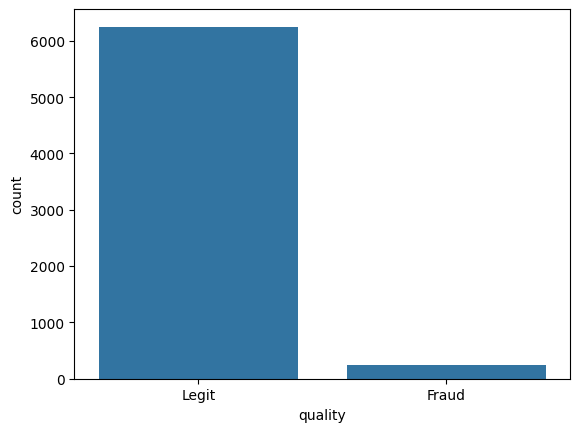

In [ ]:
sns.countplot(data=df,x='quality')


In [ ]:
#from the count there is more than 70% of data points belongs to "legit" class so it is a imbalanced data

**findout if there is any difference between red and white wine when it comes to the fraud

<Axes: xlabel='type', ylabel='count'>

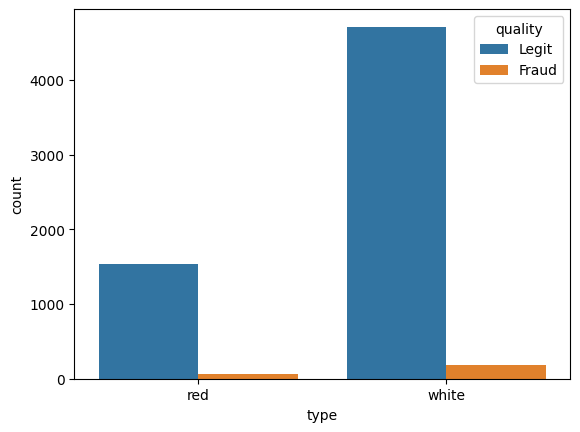

In [ ]:
sns.countplot(data=df,x='type',hue='quality')

**check what percentage of redwine are fraud and what percentage of white wine is fraud**

In [ ]:
reds=df[df['type']=='red']

In [ ]:
whites=df[df['type']=='white']

In [ ]:
print("percentage of fraud in redwine")
print(100*len(reds[reds['quality']=='Fraud'])/len(reds))

percentage of fraud in redwine
3.9399624765478425


In [ ]:
print("percentage of fraud in white wine")
print(100*len(whites[whites['quality']=='Fraud'])/len(whites))

percentage of fraud in white wine
3.736218864842793


**check the correlation between vaious columns and the features to the quality column**

**to do this we may need to map the column 0 and 1 instead of string**


In [ ]:
df['Fraud']=df['quality'].map({'Legit':0,'Fraud':1})
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,Fraud
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red,0


In [ ]:
df=df.drop(columns=['quality','type'])
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Fraud'],
      dtype='object')

In [ ]:
df.corr()["Fraud"]

,Fraud
fixed acidity,0.021794
volatile acidity,0.151228
citric acid,-0.061789
residual sugar,-0.048756
chlorides,0.034499
free sulfur dioxide,-0.085204
total sulfur dioxide,-0.035252
density,0.016351
pH,0.020107
sulphates,-0.034046


**Create barplot to check the feature relation respect to target variable**

<Axes: >

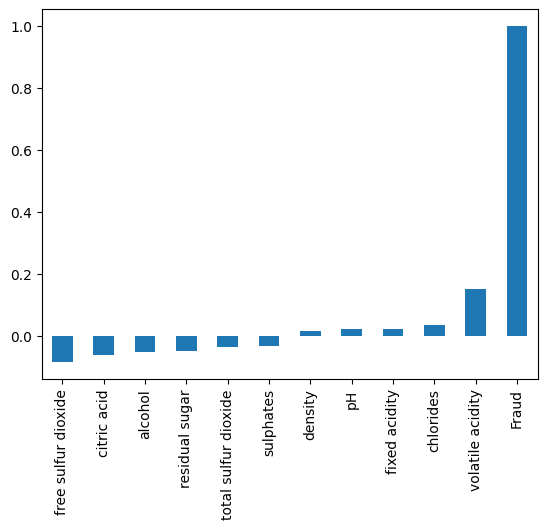

In [ ]:
df.corr()['Fraud'][::-1].sort_values().plot(kind='bar')
#last five feature has more importance

**Create a cluster map**

--- it is a kind of heatmap

---it can be build badsed on correlation



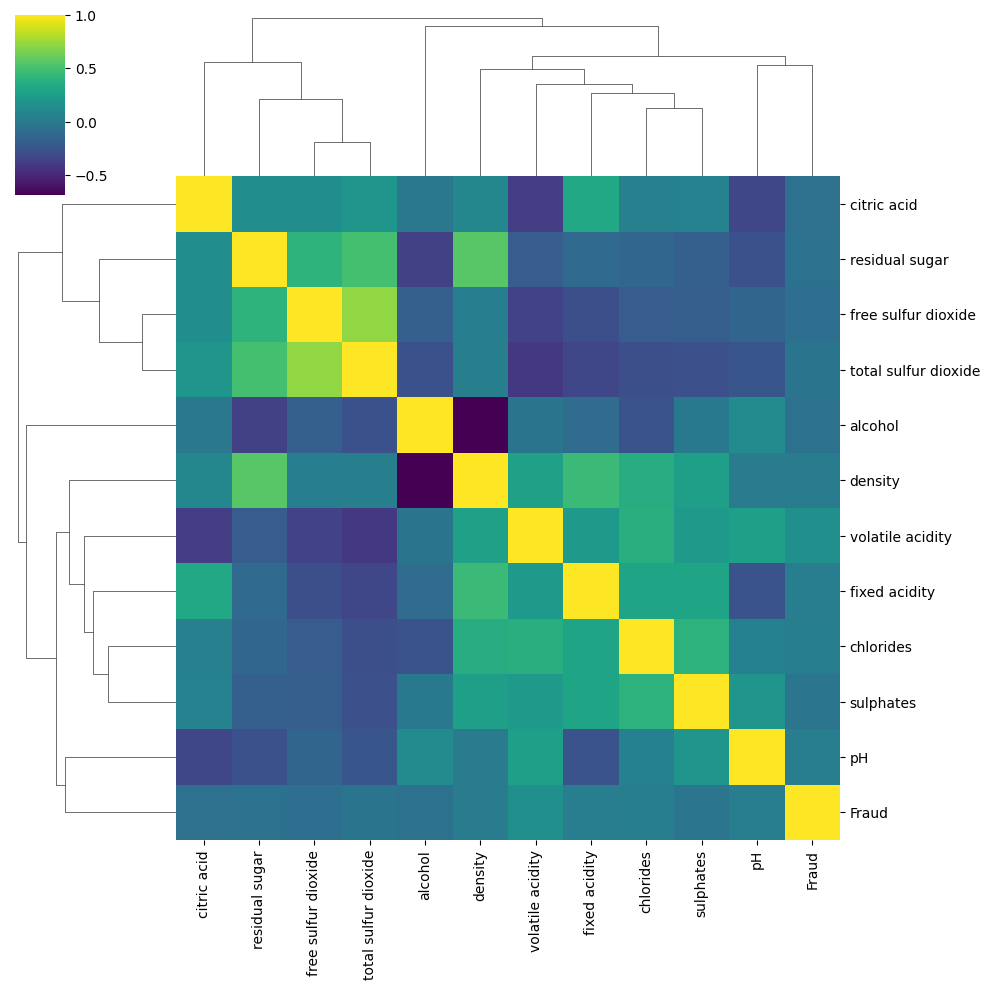

In [ ]:
sns.clustermap(df.corr(),cmap="viridis")

# Machine learning model

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Fraud'],
      dtype='object')

In [ ]:
df=pd.read_csv("/content/wine_fraud.csv")


In [ ]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
#convert the categorical columns "type" from string to dummy variable
df['type'] = pd.get_dummies(df['type'],drop_first=True)

In [ ]:
df['type']

,type
0,False
1,False
2,False
3,False
4,False
...,...
6492,True
6493,True
6494,True
6495,True


**Split the data**

In [ ]:
X = df.drop('quality',axis=1)  #feature
y = df['quality']    #target

**perform the train test split with the test size of 10% and take the random_state =101

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=101)

**scale the Xtrain and Xtest data**

In [ ]:
from sklearn.preprocessing import StandardScaler
#initialize the model
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)

**import support vector classifiers**



In [ ]:
from sklearn.svm import SVC
svc=SVC(class_weight='balanced')

**use a gridSearchCV to run grid search for best "C" and gamma parameters**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C":[0.001,0.01,0.1,0.5,1],'gamma':['scale','auto']}
grid = GridSearchCV(svc,param_grid)

In [ ]:
grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1],
                         'gamma': ['scale', 'auto']})

**display the confusion matrix and classification report for your model**

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
grid_pred = grid.predict(scaled_X_test)

In [ ]:
confusion_matrix(y_test,grid_pred)

array([[ 17,  10],
       [ 92, 531]])

In [ ]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

       Fraud       0.16      0.63      0.25        27
       Legit       0.98      0.85      0.91       623

    accuracy                           0.84       650
   macro avg       0.57      0.74      0.58       650
weighted avg       0.95      0.84      0.88       650



In [ ]:
import pickle
best_model = grid.best_estimator_
with open("svm_model.pkl","wb") as file:
  pickle.dump(best_model,file)
  print("model saved sucessfully as svm_model.pkl")

model saved sucessfully as svm_model.pkl
